Baixar dados

In [17]:
import kagglehub

path = kagglehub.dataset_download("vardhansiramdasu/fraudulent-transactions-prediction")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\luana\.cache\kagglehub\datasets\vardhansiramdasu\fraudulent-transactions-prediction\versions\1


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.under_sampling import RandomUnderSampler

#### Análise exploratória inicial do dataset

In [19]:
df = pd.read_csv(path + "/Fraud.csv")

# Informações sobre o dataset
print(df.info())
print("\n")
# Mostrar as primeiras linhas
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None




,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [20]:
# Verificar a existência de dados ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print(f"\nTotal de valores ausentes: {df.isnull().sum().sum()}")

Valores ausentes por coluna:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Total de valores ausentes: 0


In [21]:
# Verificar duplicatas
print(f"Duplicatas: {df.duplicated().sum()}")

# Estatísticas descritivas
print("\nDescribe:")
df.describe()

Duplicatas: 0

Describe:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [22]:
# Verificar distribuição da variável alvo (isFraud)
print("Quantidade nominal de amostras por classe:")
print(df['isFraud'].value_counts())
print("\nQuantidade percentual de amostras por classe:")
print(df['isFraud'].value_counts(normalize=True))

Quantidade nominal de amostras por classe:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Quantidade percentual de amostras por classe:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


Transações por tipo:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


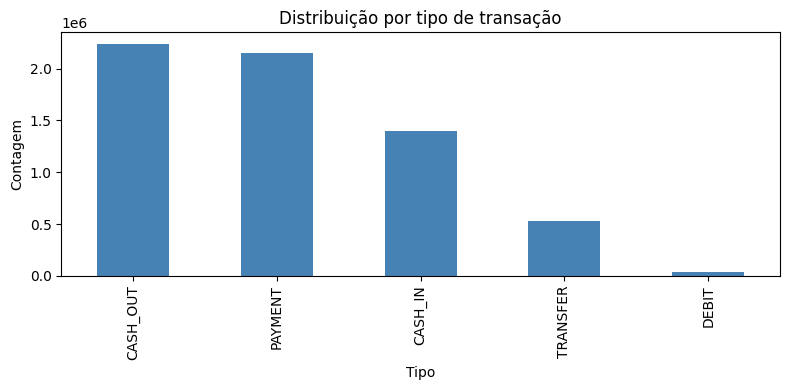

In [23]:
# Distribuição de transações por tipo
print("Transações por tipo:")
print(df['type'].value_counts())

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
df['type'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribuição por tipo de transação')
ax.set_xlabel('Tipo')
ax.set_ylabel('Contagem')
plt.tight_layout()
plt.show()

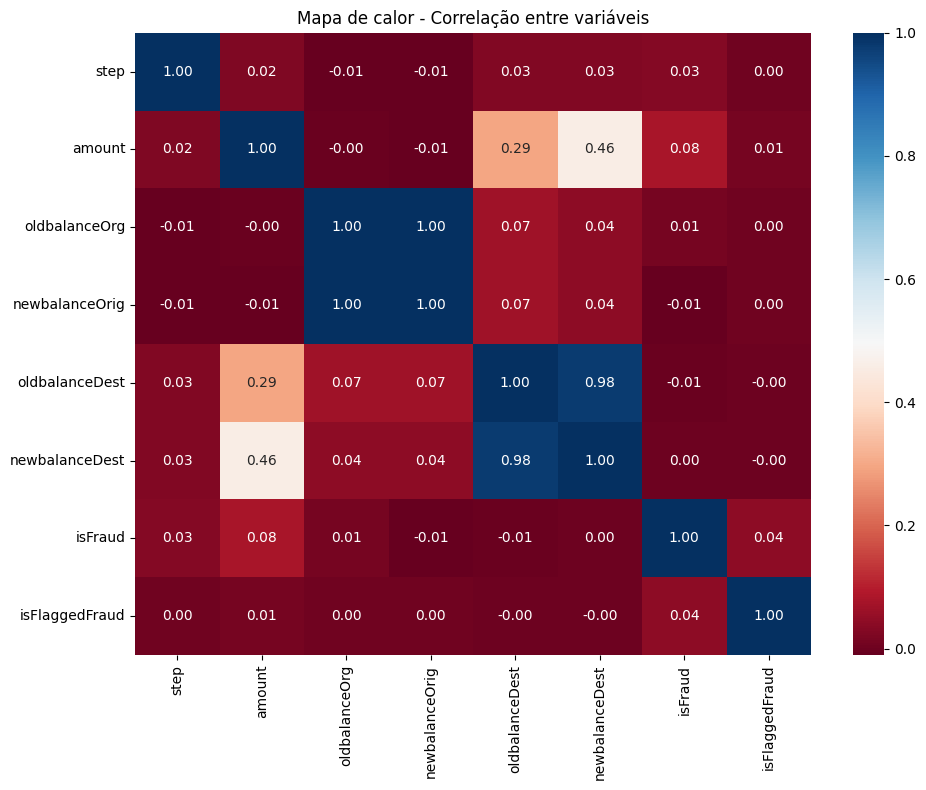

In [24]:
# Correlação entre as variáveis numéricas
df_numeric = df.select_dtypes(include='number')
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Mapa de calor - Correlação entre variáveis')
plt.tight_layout()
plt.show()

#### Pré-processamento dos dados

**Remoção de colunas:**
- `nameOrig` e `nameDest`: identificadores únicos de clientes (strings como "C1231006815"). Não carregam padrão generalizável — cada transação tem nomes distintos, o que causaria overfitting.
- `isFlaggedFraud`: coluna quase constante (~16 flags em 6.3M de transações, ou 0.0003%). Além disso, é derivada de uma regra que tenta detectar fraude (transações > 200k), o que configura potencial data leakage.

**Codificação:**
- `type`: variável categórica convertida via One-Hot Encoding para evitar que o modelo interprete uma ordem inexistente entre os tipos (importante para KNN, que usa distância).

**Normalização:**
- StandardScaler aplicado **após** o split (fit no treino, transform no teste) para evitar data leakage.

In [ ]:
# Remoção de colunas irrelevantes para o modelo

df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)

# One-Hot Encoding da variável categórica 'type'
df = pd.get_dummies(df, columns=['type'], drop_first=False)

print(f"Shape após pré-processamento: {df.shape}")
df.head()

Shape após pré-processamento: (6362620, 12)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,False,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,False,True,False


Divisao de treino e teste, 80/20

In [26]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalização: fit apenas no treino para evitar data leakage
scaler = StandardScaler()
colunas_numericas = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

print(f"Treinamento: {X_train.shape[0]} amostras ({X_train.shape[1]} features)")
print(f"Teste: {X_test.shape[0]} amostras")

# Verificar distribuição das classes no treino
print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True))

Treinamento: 5090096 amostras (11 features)
Teste: 1272524 amostras

Distribuição no treino:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


#### Balanceamento das classes (Undersampling)

O dataset é extremamente desbalanceado: apenas **0.13%** das transações são fraude. Isso é problemático para o KNN por dois motivos:

1. **Viés na classificação**: o KNN classifica pelo voto majoritário dos k vizinhos mais próximos. Com ~99.87% de amostras não-fraude, a grande maioria dos vizinhos será sempre da classe 0, fazendo o modelo ignorar fraudes.

2. **Custo computacional**: o KNN calcula a distância para **todos** os pontos de treino. Com ~5M de amostras, o tempo de predição seria inviável.

Aplica-se **Random Undersampling** na classe majoritária (apenas nos dados de treino) para equalizar as classes. O conjunto de teste permanece intocado para refletir a distribuição real.

In [28]:
# Undersampling apenas nos dados de treino
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

print(f"Antes do balanceamento: {X_train.shape[0]} amostras")
print(f"Depois do balanceamento: {X_train_bal.shape[0]} amostras")
print(f"\nDistribuição após balanceamento:")
print(y_train_bal.value_counts())
print(y_train_bal.value_counts(normalize=True))

Antes do balanceamento: 5090096 amostras
Depois do balanceamento: 13140 amostras

Distribuição após balanceamento:
isFraud
0    6570
1    6570
Name: count, dtype: int64
isFraud
0    0.5
1    0.5
Name: proportion, dtype: float64


#### Treinamento do modelo KNN

O KNN (K-Nearest Neighbors) é um algoritmo baseado em instância que classifica uma amostra pelo voto majoritário dos seus **k vizinhos mais próximos** no espaço de features.

**Escolha do k**: testamos diferentes valores de k via validação cruzada (5-fold) no conjunto de treino balanceado para encontrar o valor que maximiza o F1-score. Usamos F1-score como métrica principal porque, em detecção de fraude, tanto precisão quanto recall são importantes — queremos minimizar falsos negativos (fraudes não detectadas) sem gerar excesso de falsos positivos.

**Justificativas de pré-processamento para KNN:**
- **Normalização (StandardScaler)**: essencial para KNN pois o algoritmo usa distância euclidiana. Sem normalizar, features com escalas maiores (ex: `amount` até 92M) dominariam o cálculo de distância.
- **One-Hot Encoding**: evita impor ordem artificial nas categorias, o que distorceria a distância.
- **Undersampling**: sem balanceamento, os k vizinhos seriam quase sempre classe 0 (não-fraude), resultando em recall próximo de zero para fraudes.

k= 1 -> F1-score médio: 0.9262 (+/- 0.0049)
k= 3 -> F1-score médio: 0.9268 (+/- 0.0046)
k= 5 -> F1-score médio: 0.9241 (+/- 0.0042)
k= 7 -> F1-score médio: 0.9230 (+/- 0.0040)
k= 9 -> F1-score médio: 0.9200 (+/- 0.0057)
k=11 -> F1-score médio: 0.9193 (+/- 0.0054)
k=13 -> F1-score médio: 0.9162 (+/- 0.0050)
k=15 -> F1-score médio: 0.9144 (+/- 0.0042)
k=17 -> F1-score médio: 0.9108 (+/- 0.0050)
k=19 -> F1-score médio: 0.9101 (+/- 0.0050)
k=21 -> F1-score médio: 0.9087 (+/- 0.0036)

Melhor k: 3 (F1-score: 0.9268)


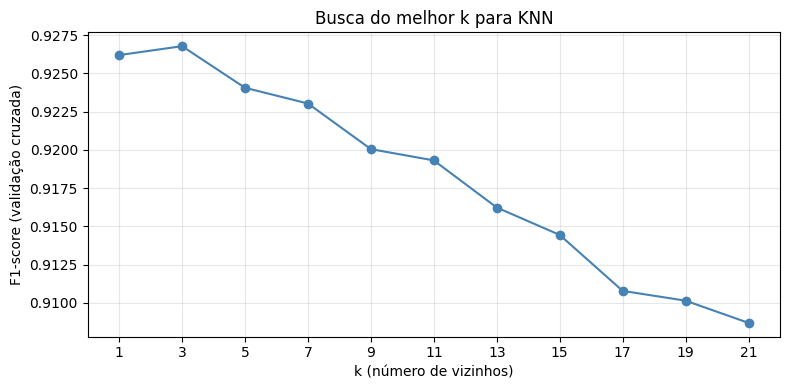

In [30]:
# Busca do melhor k via validação cruzada (F1-score)
k_values = range(1, 22, 2)  # k ímpar para evitar empates
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_bal, y_train_bal, cv=5, scoring='f1')
    f1_scores.append(scores.mean())
    print(f"k={k:2d} -> F1-score médio: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_k = list(k_values)[np.argmax(f1_scores)]
print(f"\nMelhor k: {best_k} (F1-score: {max(f1_scores):.4f})")

# Gráfico de F1-score por k
plt.figure(figsize=(8, 4))
plt.plot(k_values, f1_scores, marker='o', color='steelblue')
plt.xlabel('k (número de vizinhos)')
plt.ylabel('F1-score (validação cruzada)')
plt.title('Busca do melhor k para KNN')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# Treinar modelo final com o melhor k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_bal, y_train_bal)
print(f"Modelo KNN treinado com k={best_k}")

Modelo KNN treinado com k=3


#### Avaliação do desempenho do modelo

Avaliamos o KNN no **conjunto de teste original** (não balanceado), que reflete a distribuição real das transações. Métricas utilizadas:

- **Acurácia**: proporção total de acertos. Pode ser enganosa em datasets desbalanceados (um modelo que sempre prevê "não-fraude" teria ~99.87% de acurácia).
- **Precisão**: das transações classificadas como fraude, quantas realmente são. Importante para evitar alarmes falsos.
- **Recall (Sensibilidade)**: das fraudes reais, quantas foram detectadas. Crítico — uma fraude não detectada gera prejuízo financeiro.
- **F1-score**: média harmônica entre precisão e recall. Métrica principal para avaliar o equilíbrio.
- **Matriz de confusão**: visualização dos verdadeiros/falsos positivos e negativos.

In [32]:
# Predição no conjunto de teste
y_pred = knn_final.predict(X_test)

# Métricas de avaliação
print("=== Métricas no conjunto de teste ===\n")
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===\n")
print(classification_report(y_test, y_pred, target_names=['Não-Fraude', 'Fraude']))

=== Métricas no conjunto de teste ===

Acurácia:  0.9366
Precisão:  0.0188
Recall:    0.9373
F1-score:  0.0368

=== Classification Report ===

              precision    recall  f1-score   support

  Não-Fraude       1.00      0.94      0.97   1270881
      Fraude       0.02      0.94      0.04      1643

    accuracy                           0.94   1272524
   macro avg       0.51      0.94      0.50   1272524
weighted avg       1.00      0.94      0.97   1272524



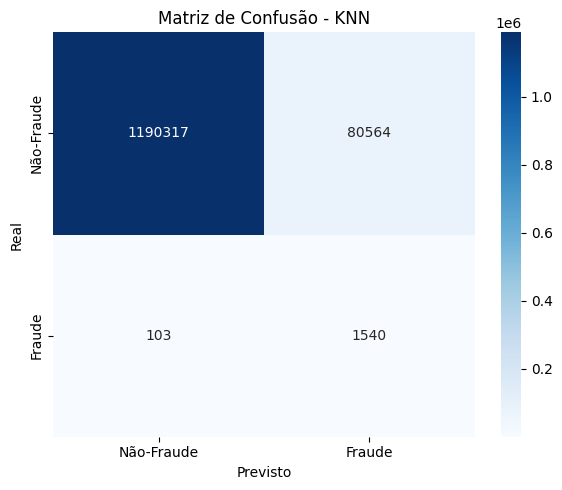


Verdadeiros Negativos: 1,190,317
Falsos Positivos:     80,564
Falsos Negativos:     103
Verdadeiros Positivos: 1,540


In [33]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não-Fraude', 'Fraude'],
            yticklabels=['Não-Fraude', 'Fraude'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - KNN')
plt.tight_layout()
plt.show()

print(f"\nVerdadeiros Negativos: {cm[0,0]:,}")
print(f"Falsos Positivos:     {cm[0,1]:,}")
print(f"Falsos Negativos:     {cm[1,0]:,}")
print(f"Verdadeiros Positivos: {cm[1,1]:,}")

#### Interpretabilidade do modelo KNN

O KNN é considerado um modelo **"caixa-preta" em termos de interpretabilidade**: não produz coeficientes nem regras explícitas — apenas compara distâncias com vizinhos. Isso torna difícil explicar **por que** uma transação foi classificada como fraude.

Para contornar isso, utilizamos técnicas model-agnostic:

- **SHAP (SHapley Additive exPlanations)**: atribui a cada feature uma contribuição marginal para a predição, baseada na teoria de jogos (valores de Shapley). O `KernelExplainer` é usado por ser compatível com qualquer modelo.
- **Permutation Importance**: mede a queda no desempenho do modelo quando os valores de uma feature são embaralhados aleatoriamente. Se a performance cai muito, a feature é importante.
- **LIME (Local Interpretable Model-agnostic Explanations)**: cria um modelo linear local ao redor de uma predição específica para explicar quais features influenciaram aquela decisão individual.

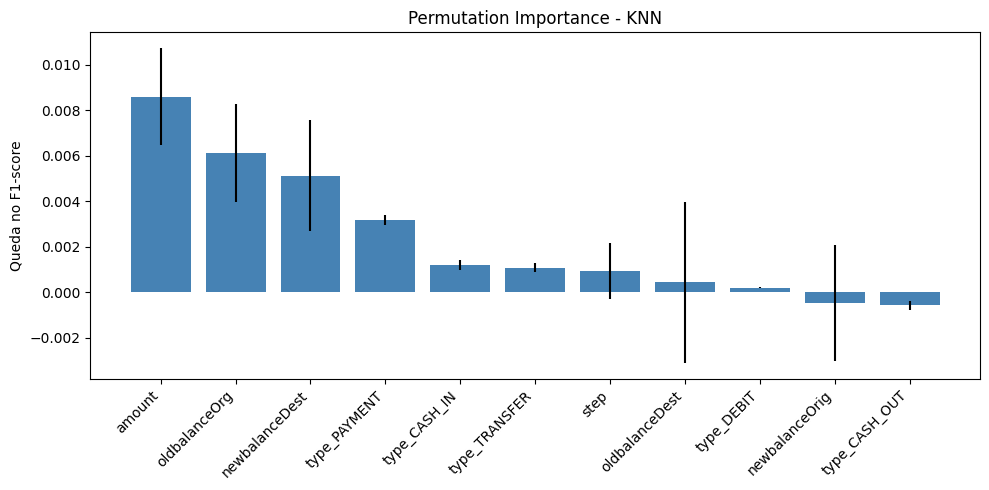

Importância por feature (Permutation Importance):
  amount              : 0.0086 +/- 0.0021
  oldbalanceOrg       : 0.0061 +/- 0.0022
  newbalanceDest      : 0.0051 +/- 0.0024
  type_PAYMENT        : 0.0032 +/- 0.0002
  type_CASH_IN        : 0.0012 +/- 0.0002
  type_TRANSFER       : 0.0011 +/- 0.0002
  step                : 0.0009 +/- 0.0012
  oldbalanceDest      : 0.0004 +/- 0.0035
  type_DEBIT          : 0.0002 +/- 0.0000
  newbalanceOrig      : -0.0005 +/- 0.0025
  type_CASH_OUT       : -0.0006 +/- 0.0002


In [34]:
# Permutation Importance
from sklearn.inspection import permutation_importance

# Usar uma amostra do teste para viabilidade computacional
sample_size = 5000
np.random.seed(42)
idx = np.random.choice(X_test.shape[0], sample_size, replace=False)
X_test_sample = X_test.iloc[idx]
y_test_sample = y_test.iloc[idx]

perm_importance = permutation_importance(knn_final, X_test_sample, y_test_sample,
                                          n_repeats=10, random_state=42, scoring='f1')

# Ordenar por importância
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(sorted_idx)), perm_importance.importances_mean[sorted_idx],
        yerr=perm_importance.importances_std[sorted_idx], color='steelblue')
plt.xticks(range(len(sorted_idx)), X_test.columns[sorted_idx], rotation=45, ha='right')
plt.ylabel('Queda no F1-score')
plt.title('Permutation Importance - KNN')
plt.tight_layout()
plt.show()

print("Importância por feature (Permutation Importance):")
for i in sorted_idx:
    print(f"  {X_test.columns[i]:20s}: {perm_importance.importances_mean[i]:.4f} +/- {perm_importance.importances_std[i]:.4f}")

**Análise da Permutation Importance:**

As features mais importantes para o KNN são:
1. **`amount`** (maior queda no F1): o valor da transação é o fator mais decisivo para distinguir fraudes. Faz sentido — fraudes tendem a envolver padrões de valores específicos.
2. **`oldbalanceOrg`**: o saldo de origem antes da transação. Fraudes frequentemente esvaziam contas, então o saldo anterior é um sinal importante.
3. **`newbalanceDest`**: o saldo do destinatário após a transação.

As features de tipo de transação (`type_PAYMENT`, `type_CASH_IN`) tiveram importância menor mas não desprezível — confirmam que o tipo influencia, mas menos que os valores monetários. Features como `type_CASH_OUT` e `newbalanceOrig` tiveram importância próxima de zero ou negativa, sugerindo que embaralhá-las não prejudica (ou até melhora ligeiramente) o modelo.

100%|██████████| 100/100 [26:19<00:00, 15.79s/it]
C:\Users\luana\AppData\Local\Temp\ipykernel_2952\3150554034.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_explain, feature_names=X_test.columns.tolist(), show=True)


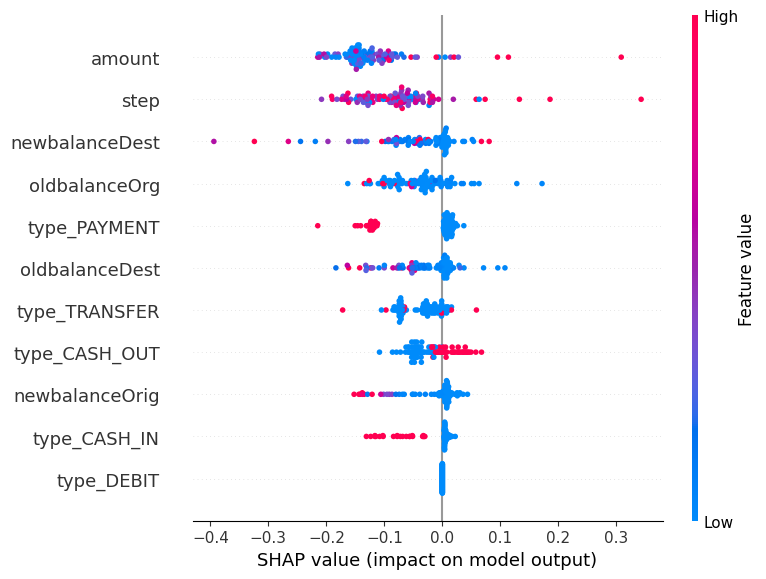

In [36]:
# SHAP - KernelExplainer (model-agnostic)
import shap

# Usar amostra pequena do treino como background (SHAP é computacionalmente caro)
background = shap.sample(X_train_bal, 100)
explainer = shap.KernelExplainer(knn_final.predict_proba, background)

# Explicar uma amostra do teste
X_explain = X_test_sample.iloc[:100]
shap_values = explainer.shap_values(X_explain)

# Summary plot: importância global das features (classe fraude = 1)
shap.summary_plot(shap_values[:, :, 1], X_explain, feature_names=X_test.columns.tolist(), show=True)

**Análise do SHAP:**

O summary plot do SHAP mostra, para cada feature, como seus valores impactam a probabilidade de classificar como fraude:
- Cada ponto é uma amostra. A posição horizontal indica se a feature **empurrou** a predição para fraude (direita) ou para não-fraude (esquerda). A cor indica o valor da feature (vermelho = alto, azul = baixo).
- **`amount`** e **`oldbalanceOrg`** aparecem no topo, confirmando os resultados da Permutation Importance.
- O SHAP vai além da Permutation Importance ao revelar a **direção** do efeito: por exemplo, valores altos de `amount` podem estar associados tanto a fraude quanto a não-fraude, enquanto o padrão de `oldbalanceOrg` pode indicar uma relação mais clara.
- As colunas one-hot de tipo contribuem de forma binária (0 ou 1), o que se reflete em clusters claros de pontos no gráfico.

C:\Users\luana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Predição do modelo: Fraude
Classe real: Não-Fraude



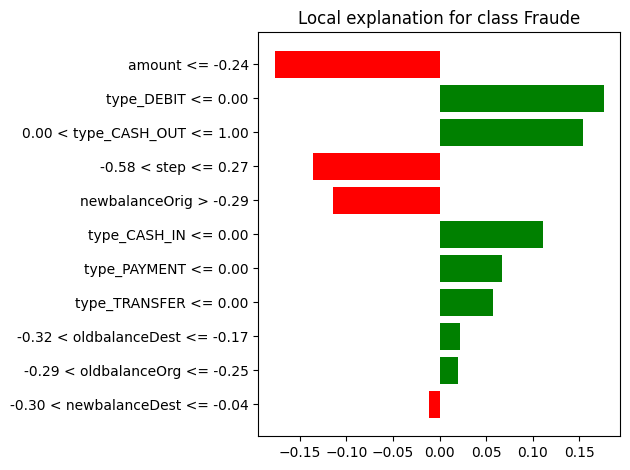

In [37]:
# LIME - Explicação de uma predição individual
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_bal.values,
    feature_names=X_train_bal.columns.tolist(),
    class_names=['Não-Fraude', 'Fraude'],
    mode='classification'
)

# Explicar uma transação classificada como fraude
fraud_indices = np.where(y_pred[idx[:100]] == 1)[0]
if len(fraud_indices) > 0:
    i = fraud_indices[0]
    exp = lime_explainer.explain_instance(X_explain.values[i], knn_final.predict_proba, num_features=11)
    print(f"Predição do modelo: {'Fraude' if y_pred[idx[i]] == 1 else 'Não-Fraude'}")
    print(f"Classe real: {'Fraude' if y_test_sample.iloc[i] == 1 else 'Não-Fraude'}\n")
    exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()
else:
    # Explicar qualquer transação se não houver fraude na amostra
    exp = lime_explainer.explain_instance(X_explain.values[0], knn_final.predict_proba, num_features=11)
    print(f"Predição do modelo: {'Fraude' if y_pred[idx[0]] == 1 else 'Não-Fraude'}")
    print(f"Classe real: {'Fraude' if y_test_sample.iloc[0] == 1 else 'Não-Fraude'}\n")
    exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

**Análise do LIME:**

O LIME explica uma predição **individual** — neste caso, uma transação que o modelo classificou como fraude. O gráfico mostra quais features mais influenciaram essa decisão específica e em que direção:
- Barras para a **direita** (laranjas) indicam features que empurraram a predição para "Fraude".
- Barras para a **esquerda** (azuis) indicam features que empurraram para "Não-Fraude".

Isso é útil num cenário prático: um analista de fraudes poderia usar o LIME para entender *por que* o sistema flaggou uma transação específica, em vez de confiar cegamente na predição. Por exemplo, se o LIME indica que o `amount` e o `oldbalanceOrg` foram os fatores decisivos, o analista pode verificar manualmente se aquela movimentação é plausível.

Note que o LIME cria um **modelo linear local** — a explicação vale apenas para aquela transação e suas vizinhanças. Transações diferentes podem ter explicações completamente distintas, o que reflete a natureza não-linear do KNN.

---

#### Conclusão

**Desempenho do KNN:**
O modelo KNN com k=3 obteve **recall de ~93.7%**, detectando a grande maioria das fraudes reais (1.540 de 1.643). Porém, a **precisão foi de apenas ~1.9%**, com ~80.564 falsos positivos. Isso significa que, para cada fraude real detectada, cerca de 52 transações legítimas são incorretamente sinalizadas.

Esse trade-off é consequência direta do undersampling agressivo: ao treinar com classes 50/50, o modelo aprende a ser muito sensível a padrões de fraude, mas no cenário real (onde fraudes são 0.13%), essa sensibilidade gera muitos alarmes falsos. Em aplicações reais de detecção de fraude, esse trade-off pode ser aceitável — o custo de perder uma fraude (falso negativo) geralmente é muito maior que o custo de investigar um alarme falso (falso positivo).

**Interpretabilidade:**
O KNN, por natureza, não oferece explicações sobre suas decisões — ele classifica por voto majoritário dos vizinhos mais próximos, mas não indica quais features contribuíram para aquela proximidade. Diferente de uma Árvore de Decisão (que produz regras legíveis) ou Regressão Logística (que tem coeficientes por feature), o KNN mistura todas as features numa única métrica de distância euclidiana, sem separar a contribuição individual de cada uma.

Para contornar essa limitação, aplicamos três técnicas model-agnostic que convergiram em conclusões consistentes:
- **Permutation Importance** (visão global): identificou `amount`, `oldbalanceOrg` e `newbalanceDest` como as features mais discriminativas — confirmando que as decisões de pré-processamento foram adequadas (remover colunas de nomes e manter features monetárias).
- **SHAP** (visão global + direcional): confirmou as mesmas features e revelou a direção do impacto — como valores específicos de cada feature empurram a predição para fraude ou não-fraude, informação que o KNN sozinho não fornece.
- **LIME** (visão local): demonstrou como explicar decisões individuais do modelo, permitindo que um analista entenda *por que* uma transação específica foi flaggeada, tornando o KNN viável em cenários onde auditoria e transparência são exigidos.

Essas técnicas transformaram o KNN de um modelo opaco ("os vizinhos votaram assim") em um modelo auditável, onde cada predição pode ser justificada em termos das features que mais contribuíram.

**Limitações do KNN:**
- **Escalabilidade**: a predição no conjunto de teste (1.27M amostras) foi demorada porque o KNN calcula distâncias para todos os pontos de treino. Modelos como Random Forest ou XGBoost seriam mais eficientes.
- **Sensibilidade a features irrelevantes**: o KNN usa todas as features no cálculo de distância, o que pode diluir o sinal de features importantes. Técnicas de seleção de features poderiam melhorar o desempenho.
- **Custo de interpretabilidade**: embora SHAP, LIME e Permutation Importance resolvam a falta de interpretabilidade nativa, eles adicionam custo computacional significativo (o SHAP com KernelExplainer levou ~26 min para apenas 100 amostras). Em produção, isso exigiria estratégias de cache ou amostragem.